# <font color='orange'>Course on ADAPTIVE COLLECTIVE SYSTEMS</font>
# <font color='orange'>1. Opinion evolution in closed community: the Voter and Sznadj models</font>

# <font color="green">Cogmaster SUP, 2026-2027</font>

*Teacher: nicolas.bredeche(at)sorbonne-universite.fr*

*Last update: 15/09/2026*


This notebook can be executed in [Google Colab](colab.research.google.com/), Jupyter Lab or Visual Code.

This first practical course will **not** be evaluated. Parts 1 and 2 are mandatory to understand the basic concepts of sociophysics models. Other parts are important but not critical. You do not have to submit your work.



---
---
---

# <font color='orange'>PREAMBULE: initialization</font>

# Voter Model simulator

**Goal:** To understand the dynamics of the Voter model and compare with outward–influence variants (Sznajd, Stauffer).  

**Focus:** consensus, scaling with system size, boundary effects, neighborhoods.

**Model recap (Voter):**
- Binary states, `Q = 2` (values in `{0,1}`).
- Arena is a grid of size `dx × dy`. 1D is the special case `dy = 1`.
- Update rule in one Monte Carlo step:
  1. pick a *focal* individual uniformly at random;
  2. pick 1 neighbor of the focal individual;
  3. the focal copies the neighbor’s state.
- Stop when either:
  - `max_iterations` reached, or
  - *consensus* (all states identical).

**Conventions:**
- We use periodic boundary conditions (PBC) optionally.
- Neighborhoods in 2D: von Neumann (4 neighbours, by defaut) or Moore (8 neighbourgs).
- RNG seed is controllable for reproducibility.

This cell contains all the necessary functions to run the Voter model. You do not have to read the code. Later (parts 3 and 4) you will have to modify small parts of it but again, a full understanding of the code is not required.

<font color='red'>*The cell below **must** be executed before anything else. Unless you modify its content, it is not required to execute it more than once per session.*</font>

In [2]:
from IPython.core import getipython
import sys
import subprocess
execute_in_notebook = True  # True if Google Colab or VS Code; False if JupyterLab in web

try:
    import google.colab
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'numba'])
except ImportError:
    pass

# Import Libraries
import time
from datetime import datetime
from datetime import date
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from numba import njit
from IPython.display import HTML
from matplotlib import rc
import matplotlib as mpl

display_info = True
display_full_stats = False

# ---- Time-series tracking ----
track_states_over_time = True               # (#iterations, #opinions)
states_over_time = []                       # list[[iter, #distinct_opinions]]

track_counts_over_time = True               # (#iterations, c0, c1, ..., c_{Q-1})
opinion_counts_over_time = []               # list[[iter, counts...]]

def set_debug(_display_info=display_info,
              _display_full_stats=display_full_stats,
              _track_states_over_time=track_states_over_time,
              _track_counts_over_time=track_counts_over_time):
    global display_info, display_full_stats, track_states_over_time, track_counts_over_time
    display_full_stats = _display_full_stats
    display_info = _display_info
    track_states_over_time = _track_states_over_time
    track_counts_over_time = _track_counts_over_time

# Matplotlib animation setup
mpl.rcParams['animation.embed_limit'] = 100
rc('animation', html='jshtml')

# Parameters — DEFAULT VALUES (voter model)
dx, dy = 30, 30        # Arena size: width x height
Q = 2                  # Number of opinions (states), integers in [0, Q-1]

num_iterations = 2_000_000
num_frames_displayed = 100
num_iterations_between_frames = int(max(1, num_iterations / max(1, num_frames_displayed)))
iterations = 0
im = ax = states = None

def make_neighbor_shifts(dx, dy):
    """Von Neumann in 2D; if dy == 1, use true 1D with only two neighbors (left/right)."""
    if dy == 1:
        # 1-D ring along x only: two neighbors
        return np.array([(0, -1), (0, 1)], dtype=np.int64)
    else:
        # 2-D periodic von Neumann: four neighbors
        return np.array([(-1, 0), (1, 0), (0, -1), (0, 1)], dtype=np.int64)

@njit
def update_states(states, dx, dy, N_steps, neighbor_shifts):
    """
    Voter rule (asynchronous):
    - Pick random site i=(y,x)
    - Pick random neighbor j
    - i adopts j's state
    Periodic boundary conditions.
    """
    nbh_len = neighbor_shifts.shape[0]
    for _ in range(N_steps):
        y = np.random.randint(0, dy)
        x = np.random.randint(0, dx)
        s = neighbor_shifts[np.random.randint(0, nbh_len)]
        ny = (y + s[0]) % dy
        nx = (x + s[1]) % dx
        states[y, x] = states[ny, nx]
    return states

def _full_counts(states, Q):
    """Return (#distinct, unique_vals_sorted_by_count, counts_sorted, full_counts[Q])."""
    flat = states.ravel()
    unique_vals, counts = np.unique(flat, return_counts=True)
    full = np.zeros(Q, dtype=np.int64)
    for u, c in zip(unique_vals, counts):
        if 0 <= u < Q:
            full[int(u)] = int(c)
    # sort the (unique,counts) pair by decreasing count for summary
    if unique_vals.size > 0:
        idx = np.argsort(-counts)
        sorted_vals = unique_vals[idx]
        sorted_counts = counts[idx]
    else:
        sorted_vals = np.array([], dtype=np.int64)
        sorted_counts = np.array([], dtype=np.int64)
    return unique_vals.size, sorted_vals, sorted_counts, full

def update(frame):
    global states, iterations, num_iterations_between_frames, im, ax, display_info, dx, dy

    if display_info and iterations == 0:
        print("__________")

    if iterations < num_iterations:
        states[:] = update_states(states, dx, dy, num_iterations_between_frames, neighbor_shifts)
        iterations += num_iterations_between_frames
        if display_info and iterations % max(1, (num_iterations // 10)) == 0:
            print(".", end="", flush=True)
            if iterations >= num_iterations:
                print()
        if track_states_over_time or track_counts_over_time:
            num_unique, sorted_vals, sorted_counts, full = _full_counts(states, Q)
            if track_states_over_time:
                states_over_time.append([int(iterations), int(num_unique)])
            if track_counts_over_time:
                opinion_counts_over_time.append([int(iterations)] + [int(x) for x in full.tolist()])

    im.set_data(states)
    ax.set_title(f"Voter model | Q={Q} | arena={dx}×{dy}\nIterations: {int(iterations)} / {num_iterations} ({int(iterations/num_iterations*100)}%)")
    return [im]

def get_stats():
    """Keep existing signature: returns (#distinct, sorted_vals, sorted_counts)."""
    num_unique, sorted_vals, sorted_counts, _ = _full_counts(states, Q)
    return num_unique, sorted_vals, sorted_counts

def display_plot(data):
    """Plot #distinct opinions vs iterations (legacy plot)."""
    global dx, dy, Q
    if not data:
        return
    data = np.array(data)
    x = data[:, 0]
    y = data[:, 1]
    plt.figure(figsize=(6, 4))
    plt.plot(x, y, marker='o', linestyle='-')
    plt.xlabel('iterations')
    plt.ylabel('#opinions')
    plt.title(f"Voter model | Q={Q} | arena={dx}×{dy}\n#opinions over time")
    plt.ylim(0, min(dx*dy, Q))
    plt.grid(True)
    plt.show()

def display_counts_plot(data_counts, Q):
    """Plot population per state through time (one line per state) on a single figure."""
    if not data_counts:
        return
    arr = np.array(data_counts, dtype=np.int64)
    iters = arr[:, 0]
    plt.figure(figsize=(7, 5))
    for s in range(Q):
        plt.plot(iters, arr[:, 1 + s], marker='o', linestyle='-', label=f'state={s}')
    plt.xlabel('iterations')
    plt.ylabel('count')
    plt.title(f"Voter model | arena={dx}×{dy}\nPopulation per state over time")
    plt.ylim(0, dx * dy)
    plt.grid(True)
    plt.legend()
    plt.show()

def run(_Q, _dx=dx, _dy=dy, _num_iterations=num_iterations, _num_frames_displayed=num_frames_displayed):
    global dx, dy, Q, num_iterations, num_frames_displayed, states, im, ax, iterations
    global states_over_time, opinion_counts_over_time, num_iterations_between_frames, neighbor_shifts, display_info

    start_time = time.time()

    if _Q < 2:
        raise ValueError("Q must be >= 2 for the voter model.")
    Q = int(_Q)
    dx, dy = int(_dx), int(_dy)
    num_iterations = int(_num_iterations)
    num_frames_displayed = int(_num_frames_displayed)
    num_iterations_between_frames = int(max(1, num_iterations / max(1, num_frames_displayed)))
    iterations = 0

    im = ax = states = None
    states_over_time = []
    opinion_counts_over_time = []

    neighbor_shifts = make_neighbor_shifts(dx, dy)

    # Initialize states uniformly at random in [0, Q-1]
    states = np.random.randint(0, Q, size=(dy, dx), dtype=np.int64)

    # Set up the plot
    fig, ax = plt.subplots()
    im = ax.imshow(states, interpolation='nearest', animated=True)
    ax.axis('off')

    # Display info
    if display_info:
        print("=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=")
        print("Model                  : Voter")
        print("Arena                  :", dx, "x", dy)
        print("Number of opinions (Q) :", Q)
        print("Iterations             :", num_iterations)
        print("Display", num_frames_displayed, "frames (every", num_iterations_between_frames, "iterations)")

    # Track initial state
    if track_states_over_time or track_counts_over_time:
        num_unique, sorted_vals, sorted_counts, full = _full_counts(states, Q)
        if track_states_over_time:
            states_over_time.append([int(iterations), int(num_unique)])
        if track_counts_over_time:
            opinion_counts_over_time.append([int(iterations)] + [int(x) for x in full.tolist()])

    ani = FuncAnimation(fig, update, frames=max(1, num_frames_displayed - 1), blit=True, repeat=False, interval=1)

    # Show animation
    if execute_in_notebook:
        display(HTML(ani.to_jshtml()))
    else:
        plt.show()

    final_num_unique, final_vals, final_counts = get_stats()

    if display_info:
        print("Number of unique opinions:", final_num_unique)
    if display_full_stats:
        print("List of opinions (with counts):")
        for v, c in zip(final_vals, final_counts):
            print("Opinion:", int(v), "Count:", int(c))

    # Plots
    if track_states_over_time:
        display_plot(states_over_time)
    if track_counts_over_time:
        display_counts_plot(opinion_counts_over_time, Q)

    elapsed_time = time.time() - start_time
    if display_info:
        print(f"{elapsed_time:.1f} sec.")

    # Extend retValues with opinion_counts_over_time
    return (final_num_unique, final_vals, final_counts, states_over_time, opinion_counts_over_time)


#### #### ####

print("\n", date.today(), datetime.now().strftime("%H:%M:%S"), "GMT")
print("OK.")



 2026-09-28 19:07:11 GMT
OK.


---
---
---

# <font color='orange'>PART 1: simulating the Voter model</font>

- run the two cells below, make sure you understand how to use the set_debug and run functions from the example below. Then, analyse the outcome of the two simulations. Write a short comment below.

- What are the absorbing states?
- For a given number of individuals, how does the structure of the environment (1D or 2D) affects the dynamics?

**Methodological hint**: *Simulation is stochastic. Run multiple simulations with the same set of parameters to obtain reliable results.*

**Technical hint**: *Simulation takes time. Be careful when setting arena size, and number of frames to be rendered.*

=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=
Model                  : Voter
Arena                  : 30 x 30
Number of opinions (Q) : 2
Iterations             : 10000000
Display 100 frames (every 100000 iterations)
__________
..........


Number of unique opinions: 1
List of opinions (with counts):
Opinion: 0 Count: 900


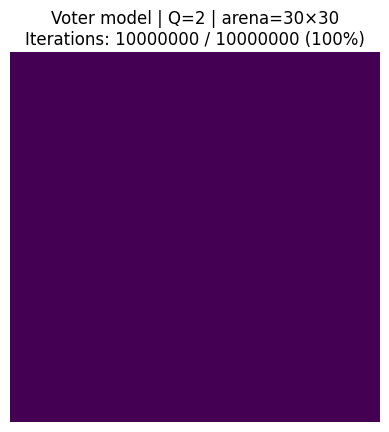

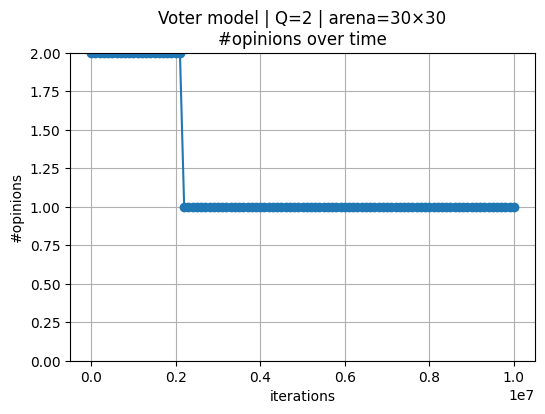

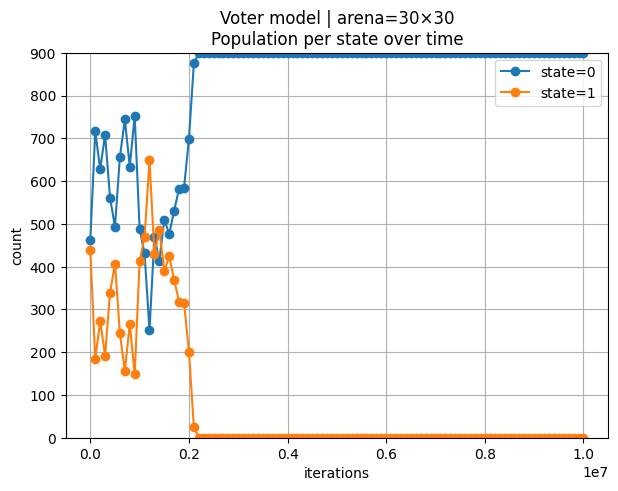

2.8 sec.


In [3]:
set_debug(_display_info=True,
          _display_full_stats=True,
          _track_states_over_time=True,
          _track_counts_over_time=True)

# 2-D voter on 30x30
retValues = run(_Q=2, _dx=30, _dy=30, _num_iterations=10000000, _num_frames_displayed=100)


=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=
Model                  : Voter
Arena                  : 900 x 1
Number of opinions (Q) : 2
Iterations             : 10000000
Display 100 frames (every 100000 iterations)
__________
..........


Number of unique opinions: 2
List of opinions (with counts):
Opinion: 1 Count: 793
Opinion: 0 Count: 107


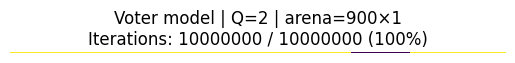

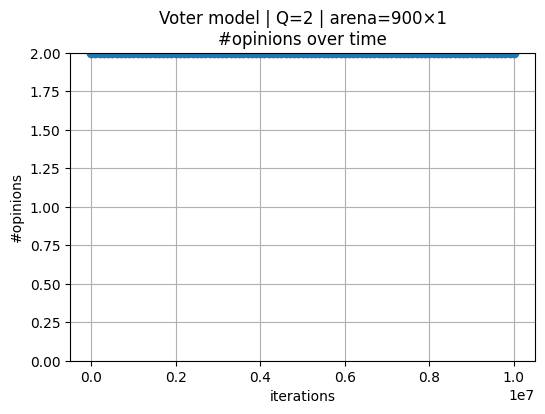

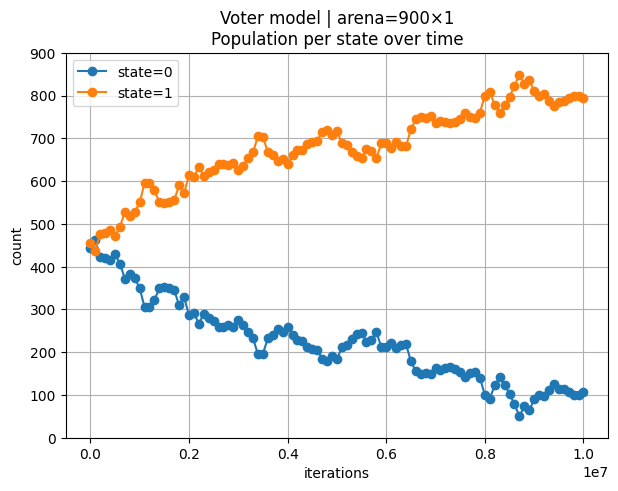

1.7 sec.


In [4]:
set_debug(_display_info=True,
          _display_full_stats=True,
          _track_states_over_time=True,
          _track_counts_over_time=True)

# 1-D voter on a ring of 200 sites (two neighbors only)
retValues = run(_Q=2, _dx=900, _dy=1, _num_iterations=10000000, _num_frames_displayed=100)


<font color='green'>Your comments:</green>

- What are the absorbing states?
>There are two opinions $Q$ absorbing states. The opinions can converge to either $0$ or $1$in the case for Q={0,1}.
- For a given number of individuals, how does the structure of the environment (1D or 2D) affects the dynamics?
>For a fixed number of individuals, the absorbing state is reached faster in an 2D environment, compared to a 1D environment.

**Methodological hint**: *Simulation is stochastic. Run multiple simulations with the same set of parameters to obtain reliable results.*

**Technical hint**: *Simulation takes time. Be careful when setting arena size, and number of frames to be rendered.*

---
---
---

# <font color='orange'>INTERLUDE: accessing statistics</font>


A note on the return values of the **run(...)** functions. These values can be very useful to build your own statistics.

retValues = (final_num_unique, final_vals, final_counts, states_over_time, opinion_counts_over_time)


- final_num_unique (int) : Number of distinct opinions at the end (1 if consensus, >1 if several opinions survive).
- final_vals (numpy.ndarray) : The opinions still present (either [0], [1], or [0, 1], etc.), sorted by how many agents hold them.
- final_counts (numpy.ndarray) : The number of agents for each opinion in final_vals. Example: [900, 100] if 900 agents are in opinion 0 and 100 in opinion 1.
- states_over_time (list of [iteration, num_unique]) : How many distinct opinions exist over time. Example: [[0, 2], [1000, 2], [5000, 1]] means the system started with 2 opinions, reached consensus at iteration 5000.
- opinion_counts_over_time (list of [iteration, count_0, count_1]) : The population of each opinion at sampled iterations. Example: [[0, 500, 500], [1000, 520, 480], (...), [5000, 1000, 0]] means 500 zeroes and 500 ones at iteration 0, then 520/480 at it=1000, then 1000/0 at it=5000

# <font color='orange'>INTERLUDE: technical hints</font>

- *You can use either plot function defined in the first cell (copy and modify it) or an external tool (e.g. Libroffice, google spreadsheet)*
- *you can call several run(-) functions in sequence within the same cell.*
- *do not forget: simulations have a stochastic part, and show one realization each only.*
- *put your answers in the cell with "your comments" in green*. You can create other cells if you wish.


---
---
---

# <font color='orange'>PART 2: Analysing the Voter Model</font>

Mean consensus time ($T_{end}$), i.e., measuring the time it takes to converge to a stable dynamic, changes with the size and structure of the environment.

- Explore $T_{end}$ for different arena length in 1D.

- Explore $T_{end}$ for different arena length in 2D (square arena).

- Can you fit or guess the function that relates time and magnetization for 1D, for 2D?

In its simplest form, the Voter model uses 2 opinions, and deterministic application of the rule (i.e., p=1 that the neighbour's state is copied).

- Try with more states (e.g., 3). Does it changes the overall dynamics?


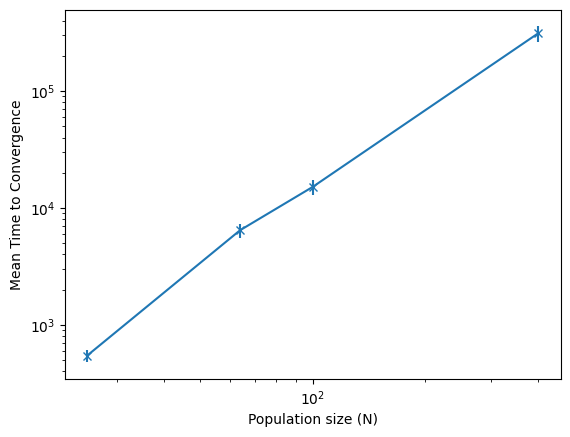

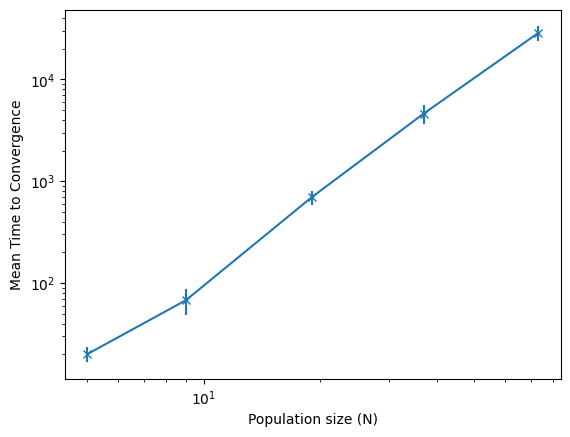

In [10]:
# your code
def consensus_time(dx, dy, Q, chunk, max_iters):
    grid = np.random.randint(low=0, high=Q, size=(dy, dx))
    t = 0
    shifts = make_neighbor_shifts(dx,dy)
    while t < max_iters:
        update_states(grid,dx,dy,chunk,shifts)
        t += chunk
        if np.all(grid.min() == grid.max()):
            return t
    return None

size = np.array([5,8,10,20,40])
r = 20
times = np.empty((len(size),r))
times[:] = np.nan

for i,side in enumerate(size):
    for j in range(0,r):
        t = consensus_time(side,side,3,side*side,10000000)
        if t is not None:
            times[i,j] = t
N = size*size
means = np.mean(times, axis=1)
valid = np.sum(np.logical_not(np.isnan(times)),axis=1)
stderr = np.std(times, axis=1)/np.sqrt(valid)


plt.errorbar(N,means,stderr,marker='x')
plt.ylabel("Mean Time to Convergence")
plt.xlabel("Population size (N)")
plt.xscale('log')
plt.yscale('log')
plt.show()

# 1D Ring

size = np.array([5,9,19,37,73])
r = 20
times = np.empty((len(size),r))
times[:] = np.nan

for i,side in enumerate(size):
    for j in range(0,r):
        t = consensus_time(side,1,2,side,10000000)
        if t is not None:
            times[i,j] = t
N = size
means = np.mean(times, axis=1)
valid = np.sum(np.logical_not(np.isnan(times)),axis=1)
stderr = np.std(times, axis=1)/np.sqrt(valid)


plt.errorbar(N,means,stderr,marker='x')
plt.ylabel("Mean Time to Convergence")
plt.xlabel("Population size (N)")
plt.xscale('log')
plt.yscale('log')
plt.show()



<font color='green'>Your comments:</green>
>The bigger the arena size, the larger $T_{end}$. This holds true in 1D and in 2D.
> In 1D it resembles an quadratic function. In 2D it resembles a logarithmic function.
> Does changing the number of states change the dynamics of the system?
>> Yes - it takes more iterations to converge.


---
---
---

# <font color='orange'>PART 3: the Sznadj Model</font>

The voter Model uses an update that flows *inward*, i.e., the state of the focal individual is updated as it *copies* others. Other models, such as the **Snadjz model** (see lecture's slides), use update rules that flow *outwards*: the focal individual *influences* others.

- Modify the original code to implement the Sznadj model in 1D (check the *update_states* function).

- Explore the mean consensus time in the Sznadj model. What do you observe?


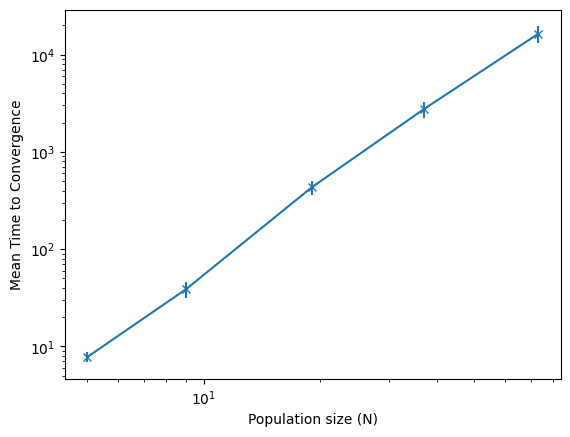

In [11]:
# your code
@njit
def update_states_sznadj(states, dx, dy, N_steps, neighbor_shifts):
    nbh_len = neighbor_shifts.shape[0]
    for _ in range(N_steps):
        y = np.random.randint(0, dy)
        x = np.random.randint(0, dx)
        xp = (x+1) % dx                                    # partner in Sznadj pair
        xl = (x-1) % dx                                    # outer partner left
        xr = (xp+1) % dx                                    # outer partner right
        if states[0, x] == states[0,xp]:
            states[0,xl] = states[0, x]
            states[0,xr] = states[0, x]
        else:
            states[0,xl] = states[0, xp]
            states[0,xr] = states[0, x]
    return states


def consensus_time_sznadj(dx, dy, Q, chunk, max_iters):
    grid = np.random.randint(low=0, high=Q, size=(dy, dx))
    t = 0
    shifts = make_neighbor_shifts(dx,dy)
    while t < max_iters:
        update_states_sznadj(grid,dx,dy,chunk,shifts)
        t += chunk
        if np.all(grid.min() == grid.max()):
            return t
    return None

size = np.array([5,9,19,37,73])
r = 20
times = np.empty((len(size),r))
times[:] = np.nan

for i,side in enumerate(size):
    for j in range(0,r):
        t = consensus_time_sznadj(side,1,2,side,10000000)
        if t is not None:
            times[i,j] = t
N = size
means = np.mean(times, axis=1)
valid = np.sum(np.logical_not(np.isnan(times)),axis=1)
stderr = np.std(times, axis=1)/np.sqrt(valid)


plt.errorbar(N,means,stderr,marker='x')
plt.ylabel("Mean Time to Convergence")
plt.xlabel("Population size (N)")
plt.xscale('log')
plt.yscale('log')
plt.show()


<font color='green'>Your comments:</green>

At these neighborhood sizes in 1D rings the two slopes show a similar increase.


---
---
---

# <font color='orange'>PART 4: Time to Magnetization, Interface Density</font>

We now consider **time to magnetization** ($T_{mag}$), i.e., measuring the time it takes to converge to a magnetization target (e.g.: ferromagnetic (all ones, all zeroes), anti-ferromagnetic (50/50 ones and zeroes), etc.).

- How does $T_{mag}$ relates to $T_{end}$ ?

- Define magnetization targets for both the Voter model and the Sznadj model.

- Compare $T_{mag}$ in the Sznadj model and the Voter model.

- The interface density, i.e., the number of neighbors that disagree, can be monitored through time. Modify the code to trace a new graph monitoring the interface density in 1D for both the Voter and Sznadj models.



In [64]:
# your code
def run_until(rule, target, dx, Q, chunk, max_iters):
    grid = np.random.randint(low=0, high=Q, size=(1, dx))
    t = 0
    shifts = make_neighbor_shifts(dx,1)
    while t < max_iters:
        rule(grid,dx,1,chunk,shifts)
        t += chunk
        label = target(grid[0])
        if label != None:                
            return t, label
    return None, None

def rho(row):
    shifted = np.roll(row,1)
    differ = row != shifted
    return np.mean(differ)

def magnetization(row):
    return 2* np.mean(row)-1

def ferromagnetic(row):
    if rho(row) == 0:
        return "consensus"
    else:
        return None

def antiferromagnetic(row):
    if rho(row) == 1:
        return "alternating"
    else:
        return None

def frozen(row):
    return ferromagnetic(row) or antiferromagnetic(row)

def threshold(theta):
    def target(row):
        if abs(magnetization(row)) >= theta:
            return "threshold"
        else:
            return None
    return target

def either (a,b):
    def target(row):
            return a(row) or b(row)
    return target




In [86]:
t, label = run_until(update_states, frozen, 73, 2, 73, 10000000)
print("Voter modle reached "+str(label)+" after " + str(t) + " iterations ")
t, label = run_until(update_states_sznadj, frozen, 74, 2, 74, 10000000)
print("Sznadj model reached "+str(label)+" after " + str(t) + " iterations ")
t, label = run_until(update_states, either(threshold(0.8), frozen), 74, 2, 74, 10000000)
print("Voter model reached "+str(label)+" after " + str(t) + " iterations ")




Voter modle reached consensus after 1971 iterations 
Sznadj model reached consensus after 10212 iterations 
Sznadj model reached threshold after 84952 iterations 


Sznajd runs ending in consensus  : 16 of 50
Sznajd runs ending in alternation: 34 of 50


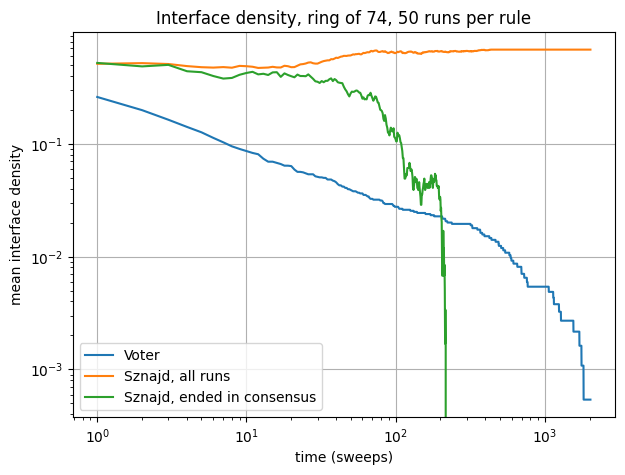

Voter                        decay exponent -0.49
Sznajd, all runs             decay exponent 0.16
Sznajd, ended in consensus   decay exponent -0.44


In [ ]:
def trace_rho(rule, L, Q, chunk, horizon):
    """One run: interface density after every chunk, no stopping. Returns an array."""
    grid = np.random.randint(low=0, high=Q, size=(1, L))
    shifts = make_neighbor_shifts(L, 1)
    row = grid[0]                          # view onto the grid: follows every update
    samples = [rho(row)]                   # value at t = 0
    for _ in range(horizon // chunk):
        rule(grid, L, 1, chunk, shifts)
        samples.append(rho(row))
    return np.array(samples)


def many_traces(rule, L, Q, chunk, horizon, R):
    """R runs stacked into an array of shape (R, number of samples)."""
    n_samples = horizon // chunk + 1
    traces = np.zeros((R, n_samples))
    for j in range(R):
        traces[j] = trace_rho(rule, L, Q, chunk, horizon)
    return traces


L = 74                      # even ring, so the Sznajd rule can reach alternation
chunk = L                   # one sweep between samples
horizon = 150_000           # about 5x the voter mean T_end at this size
R = 50

traces_voter  = many_traces(update_states,        L, 2, chunk, horizon, R)
traces_sznajd = many_traces(update_states_sznadj, L, 2, chunk, horizon, R)
t_sweeps = np.arange(horizon // chunk + 1) * chunk / L

# split the Sznajd runs by where they ended (rho = 0 consensus, rho = 1 alternating)
to_consensus   = traces_sznajd[:, -1] == 0.0
to_alternation = traces_sznajd[:, -1] == 1.0
print("Sznajd runs ending in consensus  :", int(to_consensus.sum()), "of", R)
print("Sznajd runs ending in alternation:", int(to_alternation.sum()), "of", R)

curves = {
    "Voter":                      traces_voter.mean(axis=0),
    "Sznajd, all runs":           traces_sznajd.mean(axis=0),
    "Sznajd, ended in consensus": traces_sznajd[to_consensus].mean(axis=0),
}

plt.figure(figsize=(7, 5))
for name, curve in curves.items():
    plt.plot(t_sweeps[1:], curve[1:], label=name)       # skip t = 0 on the log axis
plt.xscale('log')
plt.yscale('log')
plt.xlabel("time (sweeps)")
plt.ylabel("mean interface density")
plt.title(f"Interface density, ring of {L}, {R} runs per rule")
plt.legend()
plt.grid(True)
plt.show()

# decay exponent on the straight middle part; adjust the window by eye
window = (t_sweeps >= 5) & (t_sweeps <= 100)
for name, curve in curves.items():
    slope, _ = np.polyfit(np.log(t_sweeps[window]), np.log(curve[window]), 1)
    print(f"{name:28s} decay exponent {slope:.2f}")


<font color='green'>Your comments:</green>

Disclosure: Code for visualization of tracer was written using AI. 